# Week 6 Seminar.

## Chapter 7. Moving Beyond Linearity. ISLP textbook.

### Course: ML, 2025/2026, HSE
### Author: Oleg Melnikov, Stephan Zimin, Teaching Team.
### Revised by: Saraa Ali

In this seminar we'll study various non-linear regression techniques.

In [2]:
# let the statsmodels library to be consistent with latest pandas
!pip -q install --upgrade statsmodels

# We use same standard imports as in previous lab
# allows us to print multiple outputs from a single Colab cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# load important libraries that we might use
import numpy as np, pandas as pd, matplotlib.pylab as plt, seaborn as sns, statsmodels.api as sm
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import r2_score

# Increase viewable area of Pandas tables, numpy arrays, plots
pd.set_option('display.max_rows', 15, 'display.max_columns', 500, 'display.max_colwidth', 1, 'display.precision', 2)
np.set_printoptions(linewidth=10000, precision=4, edgeitems=20, suppress=True)
plt.rcParams['figure.figsize'] = [10, 7]


# Introduction

So far, we have mostly focused on linear models. Linear models are relatively simple to describe and implement, and have advantages over other approaches in terms of interpretation and inference. However, standard linear regression can have significant limitations in terms of predictive power. This is because the linearity assumption is almost always an approximation, and sometimes a poor one.

In this class we relax the linearity assumption
while still attempting to maintain as much interpretability as possible. We do this by examining very simple extensions of linear models like


*   Polynomial regression
*   Piecewise Step functions
*   Regression splines

We will work with synthetic data simulated using the following expression: $$ y_i = e^{-\frac{x_i^2}{6.25}} + 0.3(\epsilon_i-0.2), $$ where $\epsilon_i \sim N(0, 1)$


In [3]:
n_points = 500
x_name = 'x'
y_name = 'y'
x = np.linspace(-3., 7., n_points)
y = np.exp(-(x/2.5)**2) + (np.random.rand(n_points) - 0.2) * 0.3
data_x = pd.Series(x)
data_y = pd.Series(y)

In [4]:
# Dividing data into train and validation datasets
train_x, test_x, train_y, test_y = tts(data_x, data_y, test_size=0.4, random_state = 42)
x_grid = np.linspace(train_x.min(), train_x.max(), 100).reshape(-1, 1)

In [5]:
np.linspace(train_x.min(), train_x.max(), 100).shape

(100,)

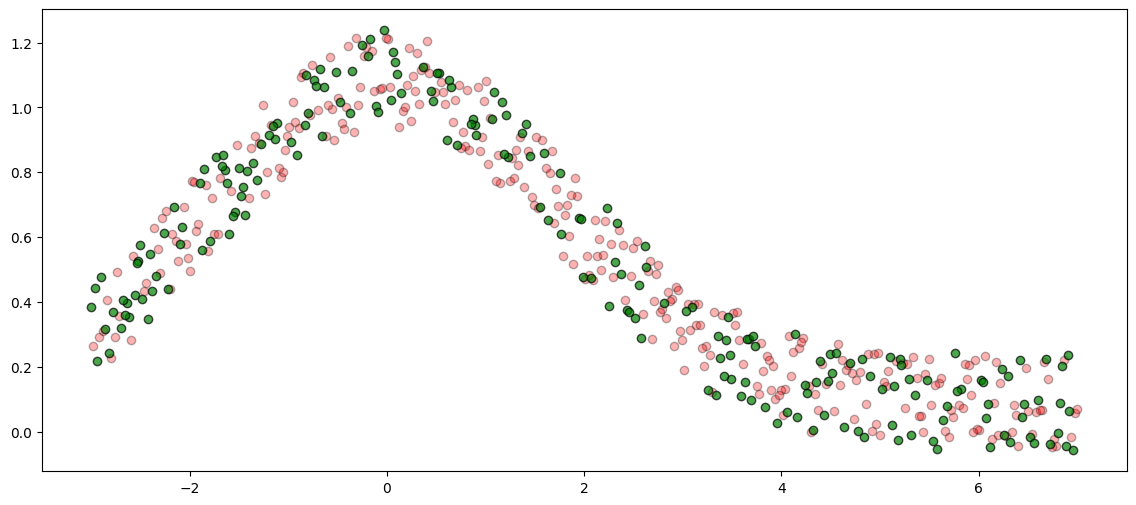

In [6]:
# Visualize the relationship b/w age and wage
plt.figure(figsize=(14, 6))
plt.scatter(train_x, train_y, edgecolor='k', alpha=0.3, color='red')
plt.scatter(test_x, test_y, edgecolor='k', alpha=0.7, color='green')
plt.show();

In [7]:
def plot_regression(x_grid, y_grid):
  plt.figure(figsize=(14, 6))
  plt.scatter(train_x, train_y, edgecolor='k', alpha=0.3, color='red')
  plt.scatter(test_x, test_y, edgecolor='k', alpha=0.7, color='green')
  plt.plot(x_grid, y_grid, color='blue', linewidth=3, label='linear regression')

## Linear regression

Recap: simple, parametric, interpretable, allow inference, "true" model:
 $$y_i = \beta_0 + \beta_1x_i + \epsilon_i,$$

Prediction:
 $$\hat{f}(x_i) = \beta_0 + \beta_1x_i$$


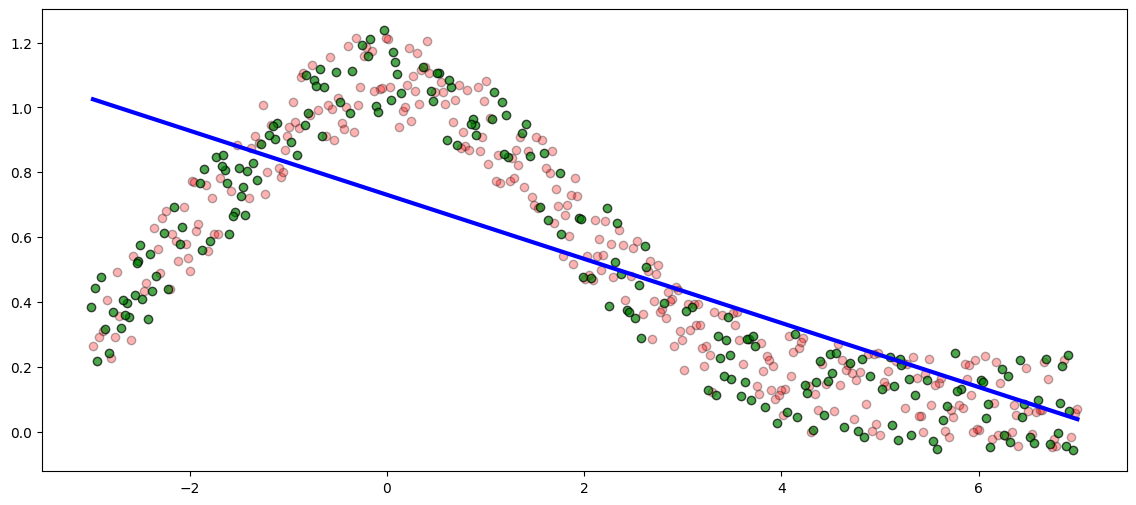

In [8]:
mdl = sm.OLS(train_y.values, sm.add_constant(train_x)).fit()    # training on train observations
y_grid = mdl.predict(sm.add_constant(x_grid))   # predicted values on the testing set
plot_regression(x_grid, y_grid)

In [9]:
print(mdl.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     372.4
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           2.11e-54
Time:                        16:51:02   Log-Likelihood:                -3.5923
No. Observations:                 300   AIC:                             11.18
Df Residuals:                     298   BIC:                             18.59
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7305      0.018     40.870      0.0

## Highly non-linear regression -- kNN

Recap: non-parametric, more flexible, "true" model -- no assumptions

Prediction:
 $$\hat{f}(x_i) = \frac{1}{k}\sum_{j \in N(x_i)}y_j$$

KNeighborsRegressor(n_neighbors=10)

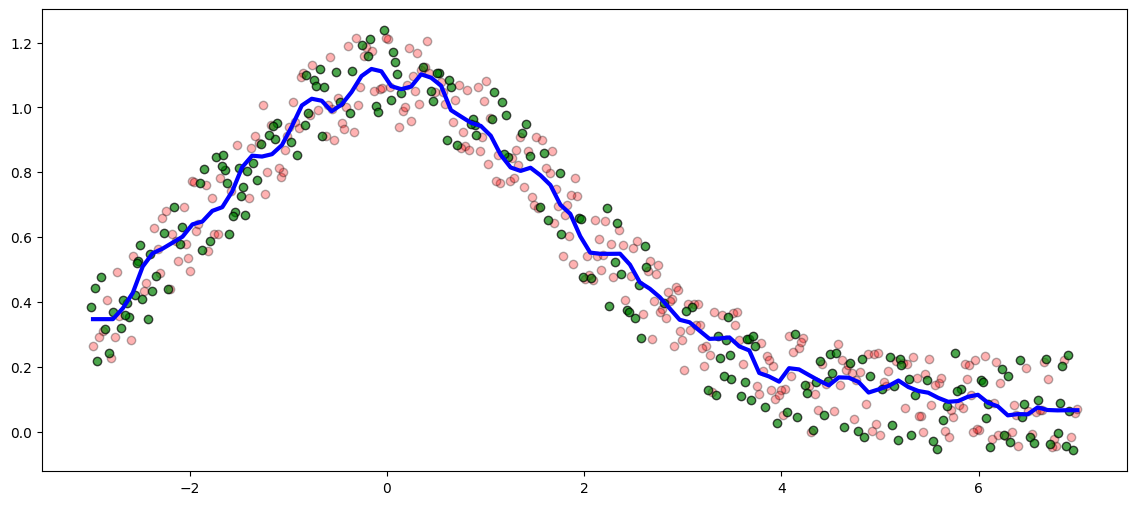

In [10]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(train_x.values.reshape(-1, 1), train_y)
y_grid = knn.predict(x_grid)
plot_regression(x_grid, y_grid)

# Moving Beyond Linearity

## Polynomial regression

Polynomial regression extends the linear model by adding extra predictors, obtained by raising each of the original predictors to a power. For example, a cubic regression uses three variables, $x$, $x^2$, and $x^3$, as predictors. This approach provides a simple way to provide a nonlinear fit to data.

Historically, the standard way to extend linear regression to settings in which the relationship between the predictors and the response is nonlinear has been to replace the standard linear model $$y_i = \beta_0 + \beta_1x_i + \epsilon_i$$ with a polynomial function $$y_i = \beta_0 + \beta_1x_i + \beta_2x_i^2 + ... + \beta_dx_i^d + \epsilon_i,$$ or $$y_i = \sum_{k=0}^d \beta_kx_i^k + \epsilon_i.$$

Notice that the coefficients $\beta_k$ can be easily estimated
using least squares linear regression because this is just a standard linear model with predictors $x_i^k$.

Generally speaking, it is unusual to use d greater than 3 or 4 because for large values of $d$, the polynomial curve can become overly flexible and can take on some very strange shapes. This is especially true near the boundary of the $x$ variable.

Here you can play with degree $d$ of a polynomial

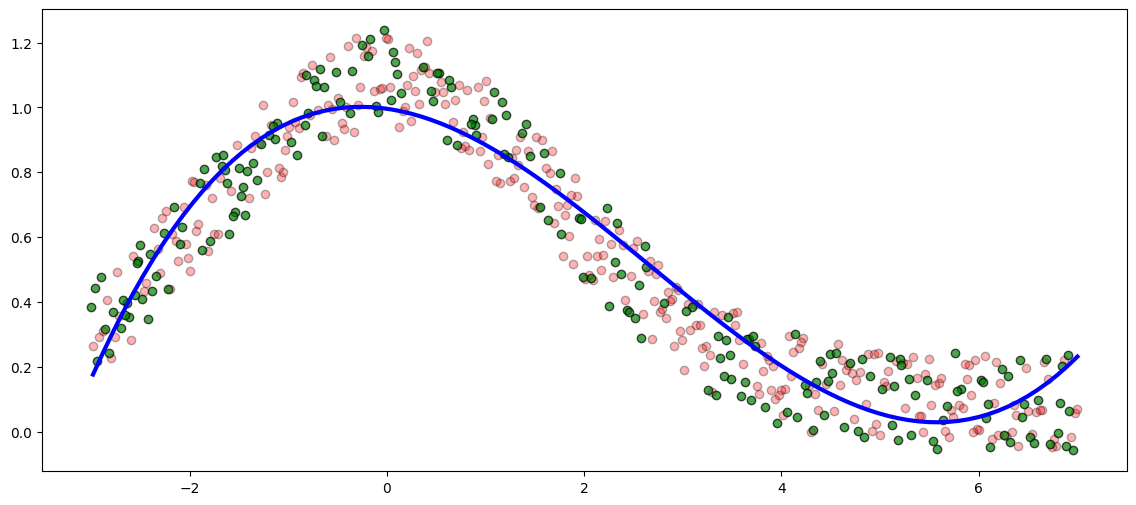

In [11]:
d = 3
from sklearn.preprocessing import PolynomialFeatures
train_x_poly = PolynomialFeatures(d).fit_transform(train_x.values.reshape(-1, 1))
grid_x_poly = PolynomialFeatures(d).fit_transform(x_grid)
mdl = sm.OLS(train_y.values, train_x_poly).fit()
y_grid = mdl.predict(grid_x_poly)
plot_regression(x_grid, y_grid)

In [12]:
print(mdl.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     1068.
Date:                Mon, 16 Feb 2026   Prob (F-statistic):          2.24e-158
Time:                        16:51:03   Log-Likelihood:                 245.31
No. Observations:                 300   AIC:                            -482.6
Df Residuals:                     296   BIC:                            -467.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9959      0.011     90.553      0.0

In [13]:
np.corrcoef(train_x_poly[:,1:].T)

array([[1.    , 0.8471, 0.8471],
       [0.8471, 1.    , 0.9788],
       [0.8471, 0.9788, 1.    ]])

## Be careful with polynomials!



An economist used cubic fit to predict the end of COVID-19 by June 2020:

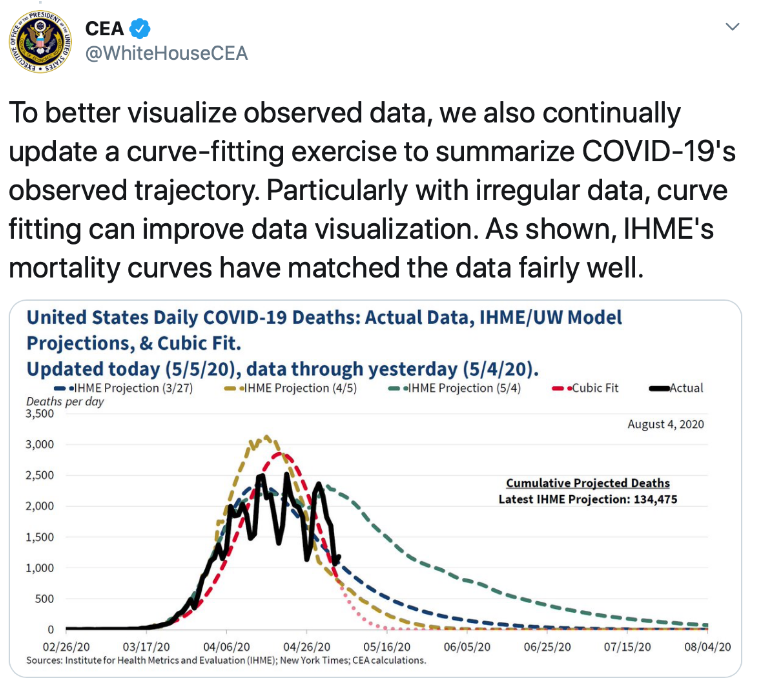

The same plot reproduced and extended further:

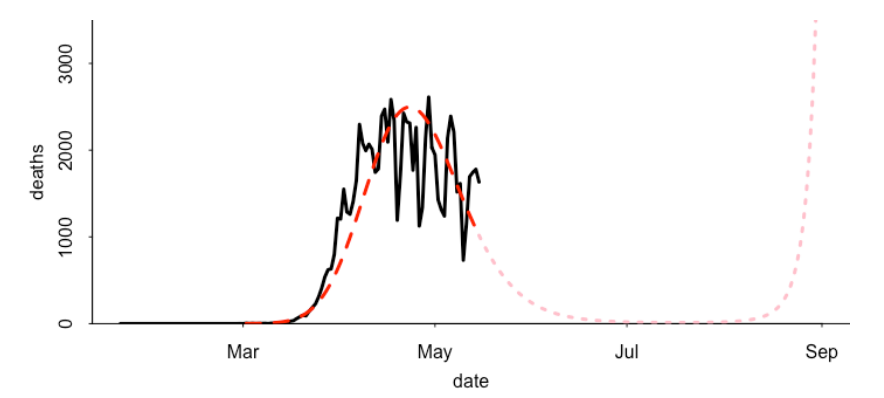

Source: https://statmodeling.stat.columbia.edu/2020/05/16/what-a-difference-a-month-makes-polynomial-extrapolation-edition/

**Question for class: Why did it happen?**

#### Answer

For the component $\beta_3 x^3$, $\beta_3$ was positive, so when $x$ increased the value exploded.  

## Piecewise Step Functions

Step functions cut the range of a variable into $K$ distinct regions in order to produce a qualitative variable. This has the effect of fitting a piecewise constant function.

Using polynomial functions of the features as predictors in a linear model imposes a global structure on the non-linear function of $x$. We can instead use step functions in order to avoid imposing such a global structure. Here step function
we break the range of $x$ into bins, and fit a different constant in each bin. This amounts to converting a continuous variable into an ordered categorical variable.

In greater detail, we create cutpoints $c_1, c_2, . . . , c_K$ in the range of $x$, and then construct $K + 1$ new variables
$$C_0(x) = I(x < c_1),$$
$$C_1(x) = I(c_1 \le x <c_2),$$
$$C_2(x) = I(c_2 \le x < c_3),$$
$$...$$
$$C_{K−1}(x) = I(c_{K−1} \le x < c_K),$$
$$C_K(x) = I(c_K \le x),$$
where $I(·)$ is an indicator function that returns a 1 if the condition is true, indicator and returns a 0 otherwise.

These are sometimes called dummy variables. Notice that for any value of $x$, $\sum_{j=0}^KC_j(x)= 1$, since $x$ must
be in exactly one of the $K + 1$ intervals.

We then use least squares to fit a linear model using $C_1(x), C_2(x), . . ., C_K(x)$ as predictors:

$$y_i = \beta_0 + \beta_1C_1(x_i) + \beta_2C_2(x_i) + ... + \beta_KC_K(x_i) + \epsilon_i,$$ or $$y_i = \beta_0 + \sum_{j=1}^K \beta_jC_j(x_i) + \epsilon_i.$$

Here you can play with the number of regions $K$

In [14]:
K = 30

df_cut, bins = pd.cut(data_x, K, retbins=True, right=False)

df_cut.head()

,0
0,"[-3.0, -2.667)"
1,"[-3.0, -2.667)"
2,"[-3.0, -2.667)"
3,"[-3.0, -2.667)"
4,"[-3.0, -2.667)"


In [15]:
df_cut.value_counts(sort=False)

,count
"[-3.0, -2.667)",17
"[-2.667, -2.333)",17
"[-2.333, -2.0)",16
"[-2.0, -1.667)",17
"[-1.667, -1.333)",17
...,...
"[5.333, 5.667)",17
"[5.667, 6.0)",17
"[6.0, 6.333)",16
"[6.333, 6.667)",17


In [16]:
bins

array([-3.    , -2.6667, -2.3333, -2.    , -1.6667, -1.3333, -1.    , -0.6667, -0.3333,  0.    ,  0.3333,  0.6667,  1.    ,  1.3333,  1.6667,  2.    ,  2.3333,  2.6667,  3.    ,  3.3333,  3.6667,  4.    ,  4.3333,  4.6667,  5.    ,  5.3333,  5.6667,  6.    ,  6.3333,  6.6667,  7.01  ])

In [17]:
bin_mapping = np.digitize(train_x, bins)
train_x_bins = pd.get_dummies(bin_mapping)

train_x_bins[y_name] = train_y.values

train_x_bins.head()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,y
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,0.08
1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.91
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.78
3,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.17
4,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.10


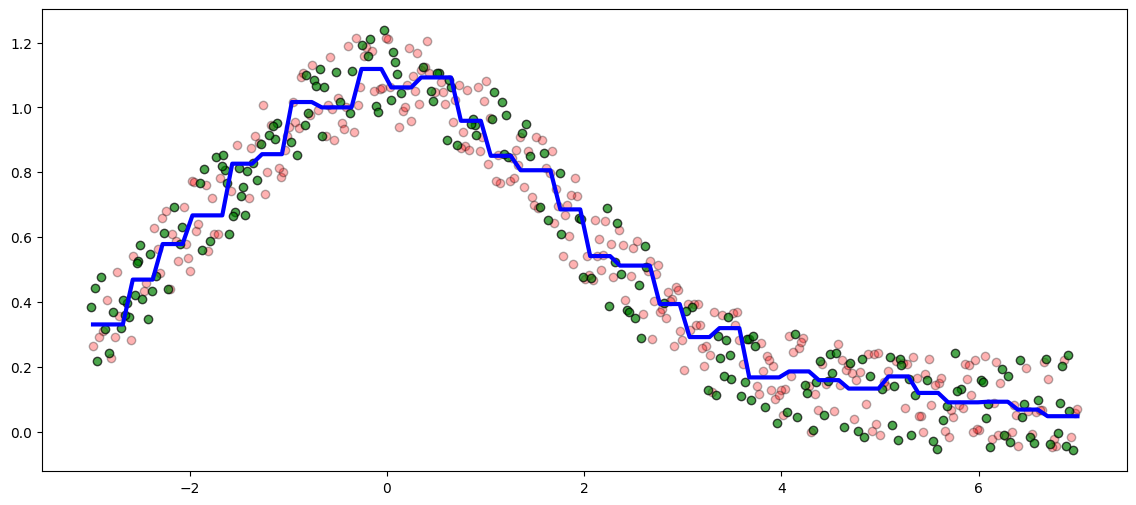

In [18]:
fit3 = sm.OLS(train_x_bins[y_name], train_x_bins.drop(columns=[y_name])).fit()

x_grid_temp = np.linspace(train_x.min(), train_x.max(), 100)

bin_mapping = np.digitize(x_grid_temp, bins)
grid_x_bins = pd.get_dummies(bin_mapping)
y_grid = fit3.predict(grid_x_bins)

plot_regression(x_grid, y_grid)

In [19]:
print(fit3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     179.5
Date:                Mon, 16 Feb 2026   Prob (F-statistic):          9.24e-159
Time:                        16:51:03   Log-Likelihood:                 326.20
No. Observations:                 300   AIC:                            -592.4
Df Residuals:                     270   BIC:                            -481.3
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
1              0.3304      0.030     10.868      0.0

## Basis functions

Polynomial and piecewise-constant regression models are in fact special cases of a basis function approach. The idea is to have at hand a family of functions or transformations that can be applied to a variable $x$: function $b_1(x), b_2(x), . . . , b_K(x)$. Instead of fitting a linear model in $x$, we fit the
model $$y_i = \beta_0 + \sum_{j=1}^K \beta_jb_j(x_i) + \epsilon_i.$$

Note that the basis functions $b_1(x), b_2(x), . . . , b_K(x)$ are fixed and known. For polynomial regression, the basis functions are $$b_j(x) = x^j,$$ and for piecewise constant functions they are $$b_j(x) = I(c_j \le x < c_{j+1}).$$

We can think of it as a standard linear model with predictors $b_1(x), b_2(x), . . . , b_K(x)$. Hence,
we can use least squares to estimate the unknown regression coefficients. Importantly, this means that all of the inference tools for linear models, such as standard errors for the
coefficient estimates and F-statistics for the model’s overall significance, are available in this setting.

Thus far we have considered the use of polynomial functions and piecewise constant functions for our basis functions; however, many alternatives are possible. For instance, we can use wavelets or Fourier series to construct basis functions. In the next section, we investigate a very common choice
for a basis function: regression splines.

## Regression splines

Regression splines are more flexible than polynomials and step
functions, and in fact are an extension of the two. They involve dividing the range of $x$ into $K$ distinct regions. Within each region, a polynomial function is fit to the data. However, these polynomials are constrained so that they join smoothly at the region boundaries, or knots. Provided that the interval is divided into enough regions, this can produce an extremely flexible fit.

Instead of fitting a high-degree polynomial over the entire range of $x$, piecewise polynomial regression involves fitting separate low-degree polynomials piecewise polynomial regression
over different regions of $x$. For example, a piecewise cubic polynomial works by fitting a cubic regression model of the form
$$y_i = \beta_0 + \beta_1x_i + \beta_2x_i^2 + \beta_3x_i^2 + \epsilon_i,$$

where the coefficients $\beta_0, \beta_1, \beta_2, \beta_3$ differ in different parts of the range of $x$. The points where the coefficients change are called knots.


For example, a piecewise cubic polynomial with a
single knot ($K=1$) at a point $c$ takes the form

$$y_i = \begin{array}{ll}
                  \beta_{01} + \beta_{11}x_i + \beta_{21}x_i^2 + \beta_{31}x_i^2 + \epsilon_i, \text{ if } x_i \le c\\
                  \beta_{02} + \beta_{12}x_i + \beta_{22}x_i^2 + \beta_{32}x_i^2 + \epsilon_i, \text{ if } x_i > c
                \end{array}$$


In other words, we fit two different polynomial functions to the data, one on the subset of the observations with $x < c$, and one on the subset of the observations with $x \ge c$. The first polynomial function has coefficients
$\beta_{01}, \beta_{11}, \beta_{21}, \beta_{31}$, and the second has coefficients $\beta_{02}, \beta_{12}, \beta_{22}, \beta_{32}$.

Each of these polynomial functions can be fit using least squares applied to simple functions of the original predictor.
Using more knots leads to a more flexible piecewise polynomial. In general, if we place $K$ different knots throughout the range of $x$, then we will end up fitting $K + 1$ different cubic polynomials. Note that we do not need to use a cubic polynomial. For example, we can instead fit piecewise
linear functions.

Here you can play with knots and degree $d$ of spline

In [20]:
# https://patsy.readthedocs.io/en/latest/spline-regression.html
from patsy import dmatrix

d = 1
knots = [-1, 2, 4]

my_spline_transformation = "bs(train, knots={knots}, degree={d}, include_intercept=True)"
my_spline_transformation = my_spline_transformation.format(
    knots=tuple(knots),
    d=d
)

transformed_train_x = dmatrix(
    my_spline_transformation,
    {"train": train_x},
    return_type='dataframe'
                              )

transformed_train_x.head()

,Intercept,"bs(train, knots=(-1, 2, 4), degree=1, include_intercept=True)[0]","bs(train, knots=(-1, 2, 4), degree=1, include_intercept=True)[1]","bs(train, knots=(-1, 2, 4), degree=1, include_intercept=True)[2]","bs(train, knots=(-1, 2, 4), degree=1, include_intercept=True)[3]","bs(train, knots=(-1, 2, 4), degree=1, include_intercept=True)[4]"
467,1.0,0.00,0.00,0.00,0.21,0.79
83,1.0,0.17,0.83,0.00,0.00,0.00
245,1.0,0.00,0.03,0.97,0.00,0.00
165,1.0,0.00,0.56,0.44,0.00,0.00
163,1.0,0.00,0.58,0.42,0.00,0.00


## Generalized Additive Model

$$y_i = \beta_0 + \sum_{j=1}^{p} f_j (x_{ij})+ \epsilon_i$$

Where $f_j$ is some non-linear function.

In our case the $f_1$ is regression splines.



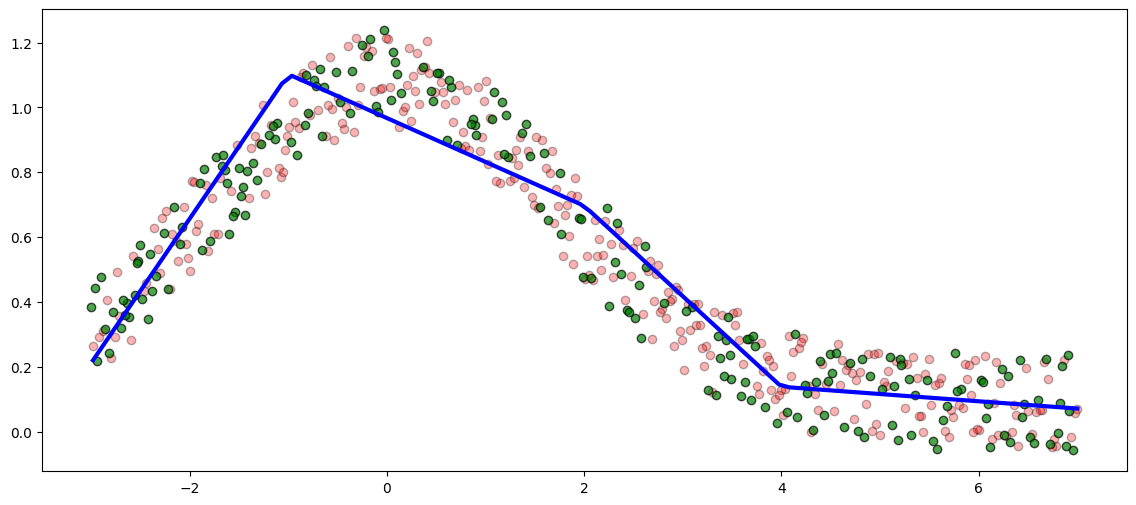

In [21]:
# Fitting Generalised linear model on transformed dataset
fit1 = sm.GLM(train_y, transformed_train_x).fit()

transformed_grid_x = dmatrix(
    my_spline_transformation,
    {"train": x_grid},
    return_type='dataframe'
    )

y_grid = fit1.predict(transformed_grid_x)

plot_regression(x_grid, y_grid)

In [22]:
print(fit1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  300
Model:                            GLM   Df Residuals:                      295
Model Family:                Gaussian   Df Model:                            4
Link Function:               Identity   Scale:                        0.012465
Method:                          IRLS   Log-Likelihood:                 234.61
Date:                Mon, 16 Feb 2026   Deviance:                       3.6760
Time:                        16:51:04   Pearson chi2:                     3.68
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9999
Covariance Type:            nonrobust                                         
                                                                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

# Extending our approach beyond univariate regression

In [40]:
def get_grid(data, border=1., step=.01):
    x_min, x_max = data[:, 0].min() - border, data[:, 0].max() + border
    y_min, y_max = data[:, 1].min() - border, data[:, 1].max() + border
    return np.meshgrid(np.arange(x_min, x_max, step),
                       np.arange(y_min, y_max, step))


def make_plot(X, y, predicted=None):

    plt.figure(figsize=(8, 8))

    if type(predicted) == np.ndarray:
        plt.pcolormesh(xx, yy, predicted, cmap='Spectral')# Extending our approach beyond univariate regression

        custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
        plt.contourf(xx, yy, predicted, alpha=0.3, cmap=custom_cmap)
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(xx, yy, predicted, cmap=custom_cmap2, alpha=0.8)




    plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', s=50, alpha=0.6)
    plt.scatter(X[y==0, 0], X[y==0, 1], c='red', s=50, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], facecolors='none', edgecolors='black', s=60)

    plt.xlabel('x1')
    plt.ylabel('x2')

    plt.show()


def plot_surface_and_scatter(xx, yy, Z, x, y, z, alpha=0.4):
  plt.figure(figsize=(12, 8))
  ax = plt.axes(projection='3d')
  ax.plot_surface(xx, yy, Z, rstride=1, cstride=1,
                  cmap='viridis', edgecolor='none', alpha=alpha);
  ax.scatter(x, y, z, color='red', linewidth=3, marker='o'); # c=z,

## Applying new methods to Multivariate case


Here again we will explore the following techniques


*   Polynomial regression
*   Piecewise Step functions
*   Regression splines

Тow we will work with 2-dimensional synthetic data simulated using the following expression: $$ z_i = \sin (-x_i) \cos(y_i) + \epsilon_i, $$ where $\epsilon_i \sim N(0, 0.1)$


In [24]:
def f(x, y):
  return np.sin(-x)*np.cos(y)

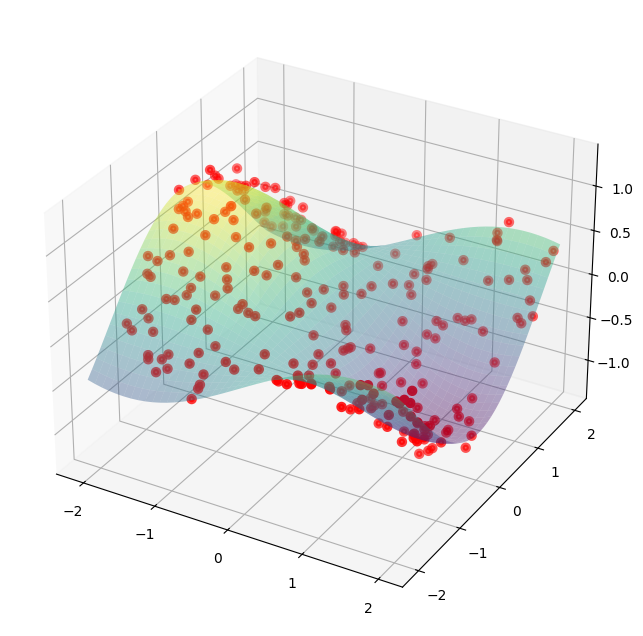

In [25]:
n = 250

# our pseudo-sample
x = np.random.uniform(-2, 2, n)
y = np.random.uniform(-2, 2, n)
z = f(x, y) + np.random.normal(scale=0.1, size=n)

# real function values on a grid
X = np.c_[x, y]
xx, yy = get_grid(X, border=0.1, step=0.1)
Z = f(xx, yy)

plot_surface_and_scatter(xx, yy, Z, x, y, z, alpha=0.4)

Apply simple polynomial transformation for $d>1$: $$ z_i = \alpha_0 + \sum_{k=1}^d \alpha_kx_i^k + \sum_{k=1}^d \beta_ky_i^k + \sum_{k=1}^d \gamma_kx_i^{d-k}y_i^k + \epsilon_i$$

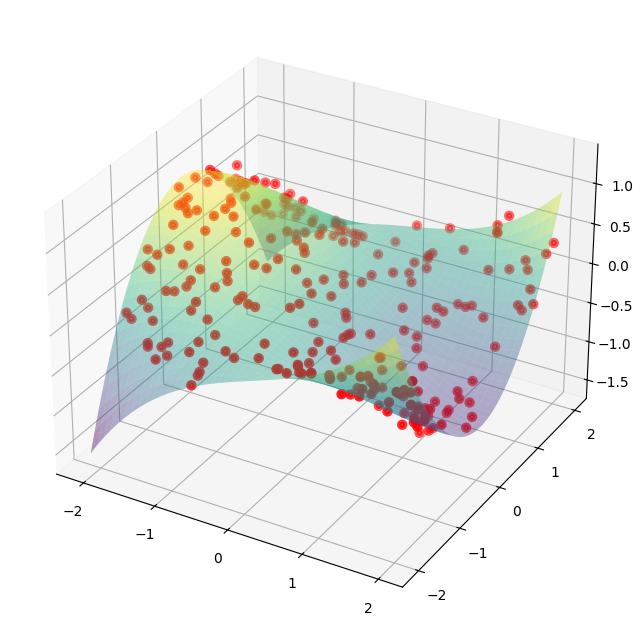

In [26]:
d = 3

X_poly = PolynomialFeatures(d).fit_transform(X)

X_grid = np.c_[xx.ravel(), yy.ravel()]
X_grid_poly = PolynomialFeatures(d).fit_transform(X_grid)

mdl = sm.OLS(z, X_poly).fit()
z_grid = mdl.predict(X_grid_poly).reshape(xx.shape)

plot_surface_and_scatter(xx, yy, z_grid, x, y, z, alpha=0.4)

Use splines (d=0 -- constants, d=1 -- linear functions, d=3 -- cubic splines) for each dimension separately ($x$ and $y$)

It doesn't take interactions into account! But you can add them manually

In [27]:
from patsy import dmatrix

d = 1
knots = [[-1, 0, 1],
         [-1, 0, 1]]

my_spline_transformation = "bs(train, knots={knots}, degree={d}, include_intercept=True)"

transformed_train_x = []
for k in range(X.shape[1]):

  my_spline_transformation_k = my_spline_transformation.format(
      knots=tuple(knots[k]),
      d=d
  )

  transformed_train_x_k = dmatrix(
      my_spline_transformation_k,
      {"train": X[:, k]},
      return_type='dataframe'
                                )

  transformed_train_x.append(transformed_train_x_k)

transformed_train_x = pd.concat(transformed_train_x, axis=1)

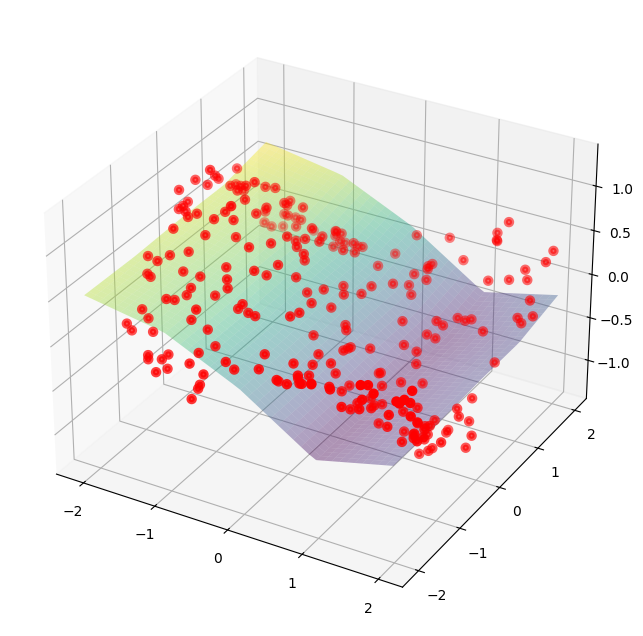

In [28]:
# Fitting Generalised linear model on transformed dataset
fit1 = sm.GLM(z, transformed_train_x).fit()

X_grid = np.c_[xx.ravel(), yy.ravel()]
transformed_grid_x = []
for k in range(X_grid.shape[1]):

  my_spline_transformation_k = my_spline_transformation.format(
      knots=tuple(knots[k]),
      d=d
  )

  transformed_grid_x_k = dmatrix(
      my_spline_transformation_k,
      {"train": X_grid[:, k]},
      return_type='dataframe'
                                )
  transformed_grid_x.append(transformed_grid_x_k)

transformed_grid_x = pd.concat(transformed_grid_x, axis=1)

z_grid = fit1.predict(transformed_grid_x).values.reshape(xx.shape)

plot_surface_and_scatter(xx, yy, z_grid, x, y, z, alpha=0.4)

#### This is not covered in a book -- just an example!

An example of 2-dimensional basis splines

In [29]:
df = 3

my_spline_transformation = "te(cr(x1, df), cc(x2, df)) - 1"

transformed_train_x = dmatrix(my_spline_transformation,
        {"x1": X[:,0], "x2": X[:,1], "df": df},
        return_type='dataframe')

transformed_grid_x = dmatrix(my_spline_transformation,
        {"x1": xx.ravel(), "x2": yy.ravel(), "df": df},
        return_type='dataframe')

transformed_train_x.head()

,"te(cr(x1, df), cc(x2, df))[0]","te(cr(x1, df), cc(x2, df))[1]","te(cr(x1, df), cc(x2, df))[2]","te(cr(x1, df), cc(x2, df))[3]","te(cr(x1, df), cc(x2, df))[4]","te(cr(x1, df), cc(x2, df))[5]","te(cr(x1, df), cc(x2, df))[6]","te(cr(x1, df), cc(x2, df))[7]","te(cr(x1, df), cc(x2, df))[8]"
0,0.08,0.99,-6.96e-02,2.26e-04,2.86e-03,-2.02e-04,-3.41e-05,-4.33e-04,3.04e-05
1,-0.08,-0.02,1.21e-02,8.27e-01,2.26e-01,-1.22e-01,1.44e-01,3.92e-02,-2.12e-02
2,-0.04,0.26,6.25e-02,-1.07e-01,7.31e-01,1.77e-01,1.12e-02,-7.67e-02,-1.85e-02
3,0.79,-0.28,3.71e-01,1.28e-01,-4.59e-02,5.99e-02,-1.92e-02,6.89e-03,-8.99e-03
4,-0.05,-0.01,6.44e-03,2.76e-01,6.45e-02,-3.61e-02,6.80e-01,1.59e-01,-8.88e-02


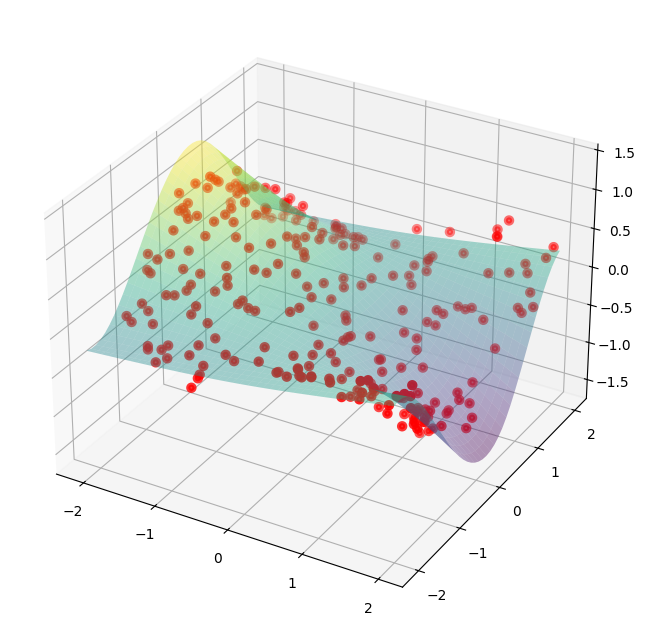

In [30]:
fit1 = sm.GLM(z, transformed_train_x).fit()
z_grid = fit1.predict(transformed_grid_x).values.reshape(xx.shape)
plot_surface_and_scatter(xx, yy, z_grid, x, y, z, alpha=0.4)

## Applying new methods to Classification task

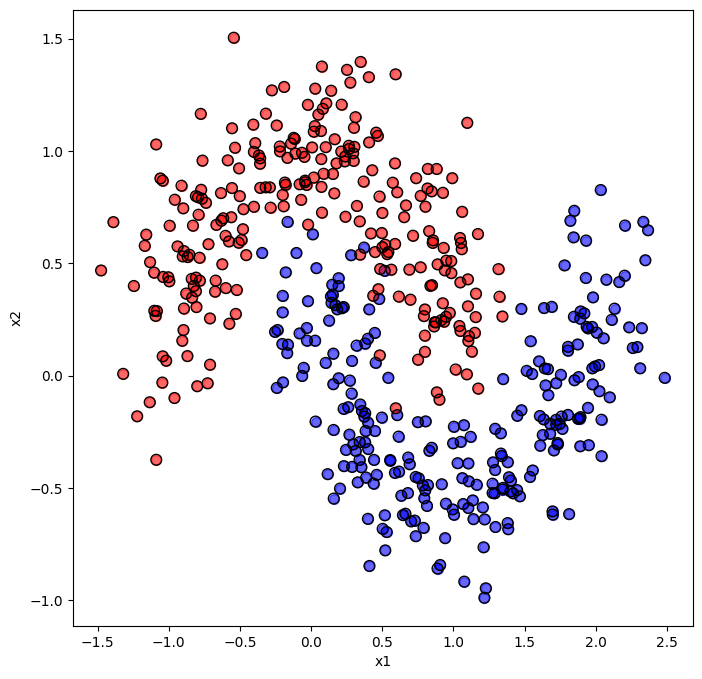

In [31]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=500, noise=0.20, random_state=42)
xx, yy = get_grid(X)
make_plot(X, y)

Simple LDA doesn't work -- need to go non-linear

LinearDiscriminantAnalysis()

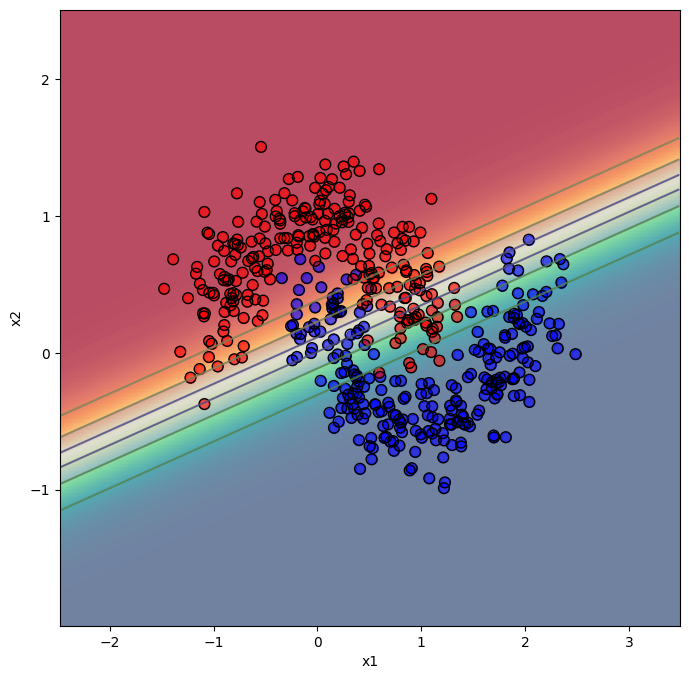

In [41]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

X_grid = np.c_[xx.ravel(), yy.ravel()]
predicted = lda.predict_proba(X_grid)[:, 1].reshape(xx.shape)

make_plot(X, y, predicted)

Polynomial features + LDA work much better!

LinearDiscriminantAnalysis()

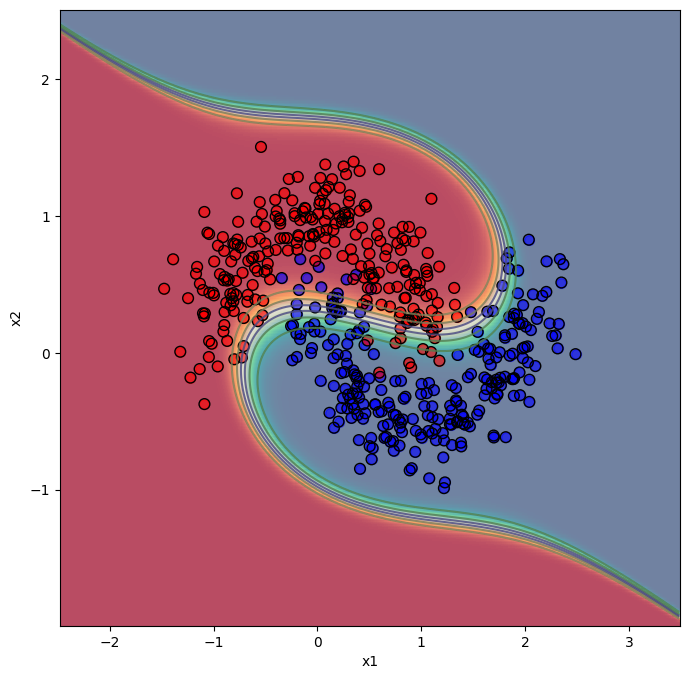

In [42]:
d = 3

X_poly = PolynomialFeatures(d).fit_transform(X)

X_grid = np.c_[xx.ravel(), yy.ravel()]
X_grid_poly = PolynomialFeatures(d).fit_transform(X_grid)

lda = LinearDiscriminantAnalysis()
lda.fit(X_poly, y)

predicted = lda.predict_proba(X_grid_poly)[:, 1].reshape(xx.shape)
make_plot(X, y, predicted)

#### This is not covered in a book -- just an example!

An example of 2-dimensional basis splines

In [43]:
from patsy import dmatrix
df = 3
my_spline_transformation = "te(cr(x1, df), cc(x2, df)) - 1"

transformed_train_x = dmatrix(my_spline_transformation,
        {"x1": X[:,0], "x2": X[:,1], "df": df},
        return_type='dataframe')

transformed_grid_x = dmatrix(my_spline_transformation,
        {"x1": xx.ravel(), "x2": yy.ravel(), "df": df},
        return_type='dataframe')

transformed_train_x.head()

,"te(cr(x1, df), cc(x2, df))[0]","te(cr(x1, df), cc(x2, df))[1]","te(cr(x1, df), cc(x2, df))[2]","te(cr(x1, df), cc(x2, df))[3]","te(cr(x1, df), cc(x2, df))[4]","te(cr(x1, df), cc(x2, df))[5]","te(cr(x1, df), cc(x2, df))[6]","te(cr(x1, df), cc(x2, df))[7]","te(cr(x1, df), cc(x2, df))[8]"
0,-0.03,-6.67e-02,2.40e-02,0.36,0.94,-0.34,0.04,1.06e-01,-3.81e-02
1,-0.03,3.03e-02,-8.20e-02,0.37,-0.32,0.87,0.07,-6.03e-02,1.63e-01
2,-0.05,-7.74e-02,3.63e-02,0.49,0.72,-0.34,0.12,1.82e-01,-8.52e-02
3,0.14,-8.51e-02,1.73e-01,0.53,-0.32,0.66,-0.05,3.29e-02,-6.69e-02
4,0.02,-4.25e-03,5.63e-03,0.93,-0.21,0.28,-0.02,3.62e-03,-4.79e-03


LinearDiscriminantAnalysis()

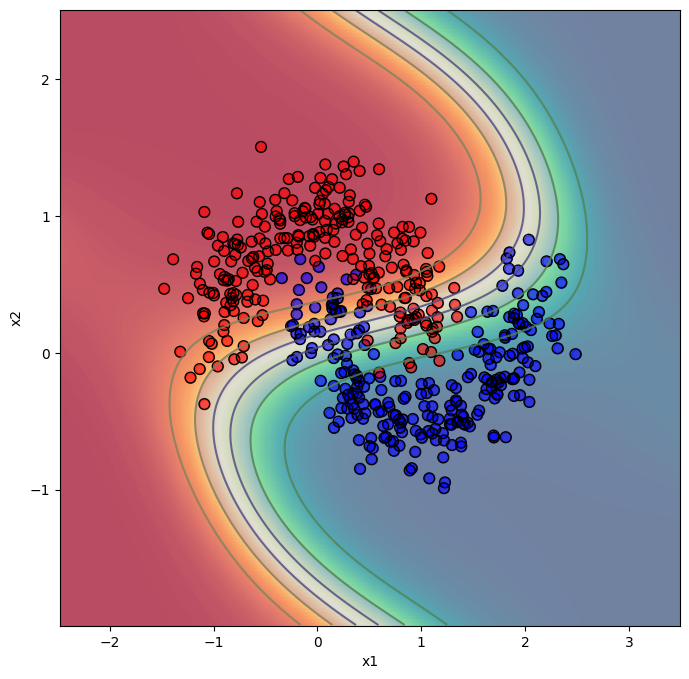

In [44]:
lda = LinearDiscriminantAnalysis()
lda.fit(transformed_train_x, y)

predicted = lda.predict_proba(transformed_grid_x)[:, 1].reshape(xx.shape)

make_plot(X, y, predicted)

# Excercises


## Mastering non-linear models

- fit linear, polynomial, piecewise step and cubic spline regression
- plot all fitted lines in one plot with different colors and legend

## Comparing and Cross Validation applied to new methods

- calculate out-of-sample $R^2$ and MAE and compare methods
- use k-fold CV to select the best $d$ for polynomial regression
- use k-fold CV to select the best $K$ for piecewise step regression
- use k-fold CV to select the best $d$ and knots for splines regression